# Laboratorium 7 - Całkowanie
Jakub Fabia

## Biblioteki

In [1]:
using Polynomials, Plots, QuadGK, DataFrames

## Zadanie 1 - Wielomiany Legendre'a

In [2]:
function legendre(n)
    P = [Polynomial([1.0]), Polynomial([0.0, 1.0])]
    for k in 1:n-1
        Pk = ((2k + 1) / (k + 1)) * Polynomial([0.0, 1.0]) * P[end] - (k / (k + 1)) * P[end-1]
        push!(P, Pk)
    end
    return P
end

legendre (generic function with 1 method)

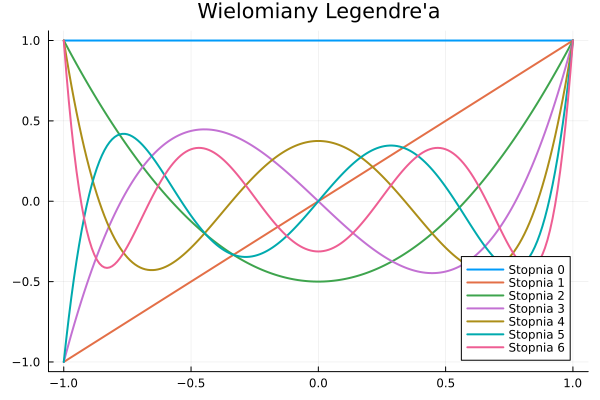

In [3]:
P = legendre(10)
x = -1:0.01:1
p = plot(
    title="Wielomiany Legendre'a"
)
for k in 1:7
    legr_poly = P[k]
    plot!(
        x,
        legr_poly.(x),
        label="Stopnia $(k-1)",
        linewidth=2
    )
end

p

In [4]:
for k in 2:5
    println("gauss:    ", sort(roots(P[k+1])))
    println("lagrande: ", sort(gauss(Float64,k)[1]))
    println()
end

gauss:    [-0.5773502691896258, 0.5773502691896256]
lagrande: [-0.5773502691896258, 0.5773502691896258]

gauss:    [-0.7745966692414834, 0.0, 0.7745966692414835]
lagrande: [-0.7745966692414834, 0.0, 0.7745966692414834]

gauss:    [-0.8611363115940536, -0.33998104358485653, 0.3399810435848563, 0.8611363115940531]
lagrande: [-0.8611363115940526, -0.3399810435848563, 0.3399810435848563, 0.8611363115940526]

gauss:    [-0.9061798459386644, -0.5384693101056823, 0.0, 0.5384693101056831, 0.9061798459386631]
lagrande: [-0.906179845938664, -0.5384693101056831, 0.0, 0.5384693101056831, 0.906179845938664]



Widać, że pierwiastki wielomianów Lagrande'a stopnia k są równe punktom odcięcia (punktach próbkowania funkcji) Gaussa k-tego stopnia.

**Podstawowe twierdzenie kwadratur Gaussa**

Odcięte $x_i$ n-punktowej kwadratury Gaussa z funkcją ważącą $w(x)$ w $[a,b]$ są zerami wielomianu ortogonalnego $\phi_{n}(x)$ dla tego samego przedziału i tej samej funkcji ważącej.

## Zadanie 2 - Kwadratura Gaussa na przedziale -1 do 1

In [5]:
function base_integrate(f, k)
    (points, weights) = gauss(k)
    return sum(weights .* f.(points))
end

base_integrate (generic function with 1 method)

In [6]:
test = [[if j != i  rand(0:10) else i end for i in 1:j] for j in 1:10]

10-element Vector{Vector{Int64}}:
 [1]
 [5, 2]
 [1, 2, 3]
 [0, 1, 3, 4]
 [5, 4, 5, 1, 5]
 [5, 2, 6, 5, 1, 6]
 [6, 8, 9, 3, 1, 8, 7]
 [3, 7, 10, 10, 1, 2, 10, 8]
 [8, 5, 2, 2, 3, 10, 9, 10, 9]
 [1, 6, 3, 0, 5, 0, 10, 4, 9, 10]

In [7]:
test_frame = DataFrame(quad_deg = Int64[], poly_deg = Int64[], gauss_val = Float64[], exp_val = Float64[])
for i in 1:10
    poly = Polynomial(test[i])
    push!(test_frame, [3 i-1 base_integrate(poly,3) quadgk(poly, -1, 1)[1]])
end
test_frame

Row,quad_deg,poly_deg,gauss_val,exp_val
,Int64,Int64,Float64,Float64
1,3,0,2.0,2.0
2,3,1,10.0,10.0
3,3,2,4.0,4.0
4,3,3,2.0,2.0
5,3,4,15.3333,15.3333
6,3,5,14.4,14.4
7,3,6,20.08,20.4
8,3,7,15.4667,15.9238
9,3,8,21.9893,23.1048


Testuje dla stopia kwatratury wynoszącego **3**.
Całka przestaje być dokładna około **7** stopnia wielomianu, co jest wynikiem spodziewanym ze względu na **twierdzenie o stopniu dokładności kwadratury Gaussa**.

#### **Twierdzenie o stopniu dokładności kwadratury Gaussa**

Kwadratura ma stopień dokładności **2n-1** dla **n** punktowej kwadratury.

## Zadanie 3 - Kwadratura Gaussa na dowolnym przedziale

In [8]:
function area_integrate(f, k, a, b)
    (points, weights) = gauss(k)
    transformed_points = ((b + a) / 2) .+ ((b - a) / 2) .* points
    return ((b-a)/2) * sum(weights .* f.(transformed_points))
end

area_integrate (generic function with 1 method)

In [9]:
fun = Polynomial([-5, 1, 0, -2, 3])
for i in 1:6
    println("Degree $i Value: $(area_integrate(fun, i, 1, 3))")
end
println("Expected value: 99.2")

Degree 1 Value: 58.0
Degree 2 Value: 98.66666666666664
Degree 3 Value: 99.19999999999999
Degree 4 Value: 99.20000000000002
Degree 5 Value: 99.19999999999997
Degree 6 Value: 99.2
Expected value: 99.2


In [10]:
fun = exp
for i in 1:6
    println("Degree $i Value: $(area_integrate(fun, i, 1, 3))")
end
println("Expected value: $(exp(3)-exp(1))")

Degree 1 Value: 14.7781121978613
Degree 2 Value: 17.310312816310365
Degree 3 Value: 17.36677141740497
Degree 4 Value: 17.36725291398744
Degree 5 Value: 17.367255088634295
Degree 6 Value: 17.36725509471703
Expected value: 17.367255094728623


In [11]:
fun = cos
for i in 1:6
    println("Degree $i Value: $(area_integrate(fun, i, 1, 2pi))")
end
println("Expected value: $(-sin(1))")

Degree 1 Value: -4.636431296816237
Degree 2 Value: -0.21168193007914166
Degree 3 Value: -0.8817726896761253
Degree 4 Value: -0.8401404904848996
Degree 5 Value: -0.8414977911075642
Degree 6 Value: -0.8414706206440855
Expected value: -0.8414709848078965


In [12]:
fun = Polynomial([-7,2,0,-1,0,4,1,-5,0,-3,2])

for i in 1:8
    println("Degree $i Value: $(area_integrate(fun, i, -2, 2.5))")
end
println("Expected value: 1550.3065467735373")

Degree 1 Value: -29.303051948547363
Degree 2 Value: -128.14810180664068
Degree 3 Value: 386.63519035034216
Degree 4 Value: 1183.7987613742494
Degree 5 Value: 1506.4359158262914
Degree 6 Value: 1550.3065467735407
Degree 7 Value: 1550.3065467735394
Degree 8 Value: 1550.306546773537
Expected value: 1550.3065467735373


## Zadanie 4 - QuadGK

In [13]:
fun = Polynomial([-7,2,0,-1,0,4,1,-5,0,-3,2])
println(quadgk(fun, -2, 2.5))

(1550.3065467735373, 1.3642420526593924e-12)


In [14]:
normal_distribution = x -> 1/sqrt(2*pi) * exp(-x^2 / 2)
quadgk(normal_distribution, -Inf,Inf)

(1.0000000000032583, 1.4395584886006938e-8)

## Zadanie 5 - Całkowanie metodą prostokątów, trapezów i Simpsona

In [15]:
function rectangle_integrate(f, n, a, b)
    h = (b-a)/n
    x = a+(h/2):h:b
    y = f.(x)
    return h * sum(y)
end

rectangle_integrate (generic function with 1 method)

In [16]:
function trapezoid_integrate(f, n, a, b)
    h = (b - a) / n
    x = a:h:b
    y = f.(x)
    return h * (0.5 * y[1] + sum(y[2:end-1]) + 0.5 * y[end])
end

trapezoid_integrate (generic function with 1 method)

In [17]:
function simpson_integrate(f, n, a, b)
    if n % 2 != 0
        error("n must be even")
    end
    h = (b - a) / n
    x = a:h:b
    y = f.(x)

    result = y[1] + y[end] + 4 * sum(y[2:2:end-1]) + 2 * sum(y[3:2:end-2])
    
    return (h / 3) * result
end

simpson_integrate (generic function with 1 method)

In [18]:
fun = x -> 3^x + 2^x
exact = 242/(9*log(3)) + 31/log(16)
test_frame3 = DataFrame(points = Int64[], rectangle = Float64[], trapezoid = Float64[], simpson = Float64[])
for i in 2:2:40
    push!(test_frame3, [
        i 
        (abs(rectangle_integrate(fun, i, -2, 3)-exact)*i)/5 
        (abs(trapezoid_integrate(fun, i, -2, 3)-exact)*i)/5 
        (abs(simpson_integrate(fun, i, -2, 3)-exact)*i)/5
    ])
end

In [19]:
fun = sin
exact = 0

test_frame4 = DataFrame(points = Int64[], rectangle = Float64[], trapezoid = Float64[], simpson = Float64[])
for i in 2:2:40
    push!(test_frame4, [
        i 
        (abs(rectangle_integrate(fun, i, 0, 2pi)-exact)*i)/2pi 
        (abs(trapezoid_integrate(fun, i, 0, 2pi)-exact)*i)/2pi 
        (abs(simpson_integrate(fun, i, 0, 2pi)-exact)*i)/2pi
    ])
end

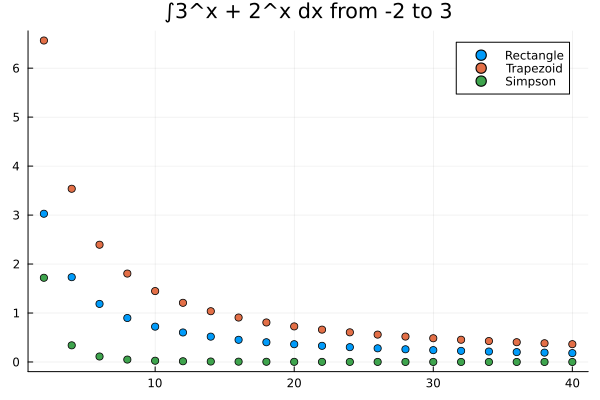

In [20]:
scatter(
    test_frame3.points,
    test_frame3.rectangle,
    label="Rectangle",
    title="∫3^x + 2^x dx from -2 to 3"
)
scatter!(
    test_frame3.points,
    test_frame3.trapezoid,
    label="Trapezoid"
)
scatter!(
    test_frame3.points,
    test_frame3.simpson,
    label="Simpson"
)

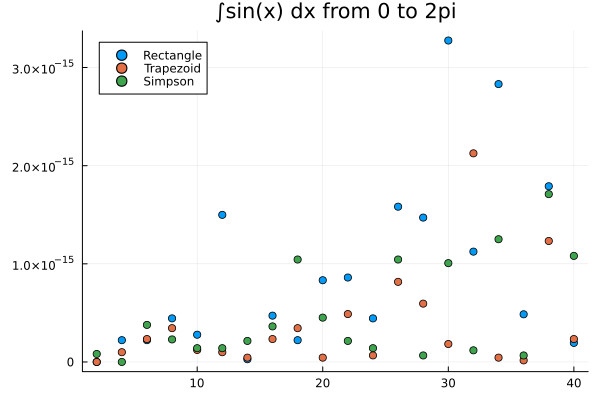

In [21]:
scatter(
    test_frame4.points,
    test_frame4.rectangle,
    label="Rectangle",
    title="∫sin(x) dx from 0 to 2pi"
)
scatter!(
    test_frame4.points,
    test_frame4.trapezoid,
    label="Trapezoid"
)
scatter!(
    test_frame4.points,
    test_frame4.simpson,
    label="Simpson"
)